In [85]:
import pandas as pd
# This path looks back one folder to find your cleaned data from last week
df = pd.read_csv('../Week 1/cleaned_sales_data.csv')
df.head() # Add this line to verify the data loaded correctly

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5068\3545560962.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')


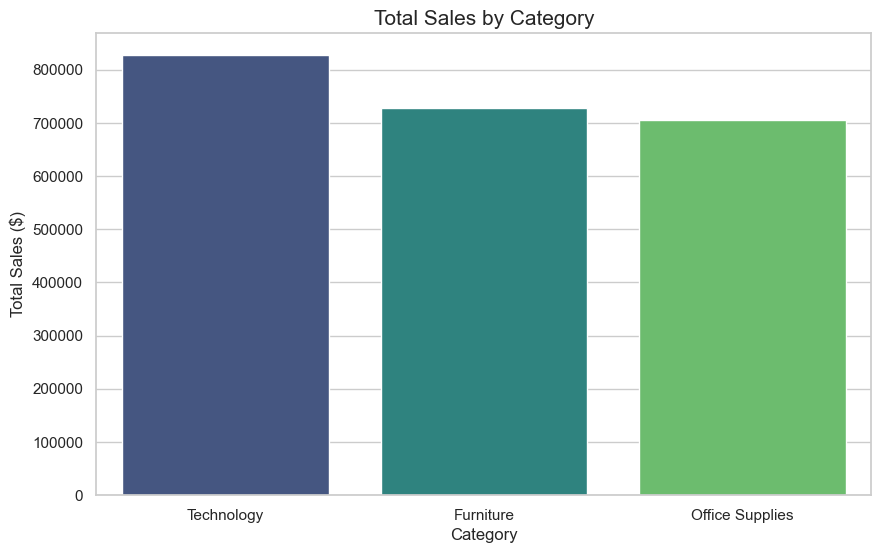

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Aggregate data for the plot
category_sales = df.groupby('category')['sales'].sum().reset_index().sort_values(by='sales', ascending=False)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')

# Add labels and title
plt.title('Total Sales by Category', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

plt.show()

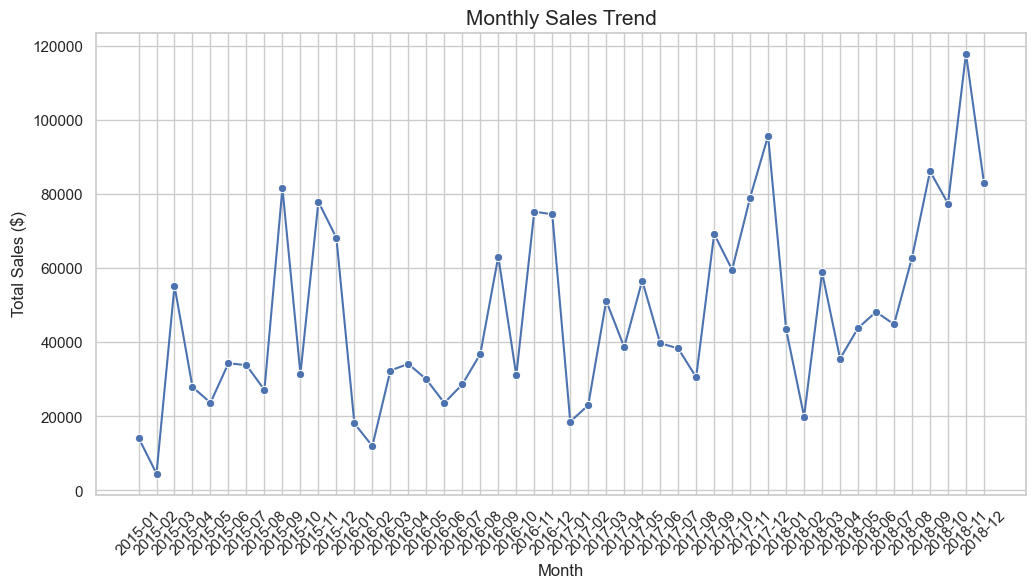

In [87]:
# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Create a 'Year-Month' column for grouping
df['month_year'] = df['order_date'].dt.to_period('M')

# Aggregate sales by month
monthly_sales = df.groupby('month_year')['sales'].sum().reset_index()
monthly_sales['month_year'] = monthly_sales['month_year'].astype(str)

# Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='month_year', y='sales', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.show()

In [88]:
# Convert all column names to lowercase to make coding easier
df.columns = [col.lower() for col in df.columns]
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'month_year'],
      dtype='object')


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# First, let's check what your actual DataFrame looks like
print("=== DEBUGGING START ===")

# 1. Check if df exists and its structure
try:
    print(f"Type of df: {type(df)}")
    print(f"Shape of df: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())
except NameError:
    print("Error: 'df' is not defined!")
    # You need to load your data first
    # Uncomment and modify one of these:
    # df = pd.read_csv('cleaned_sales_data.csv')
    # df = pd.read_csv('train.csv')
    # df = pd.read_csv('category_summary.csv')
    exit()

# 2. Print all column names to see what you actually have
print("\n=== ALL COLUMNS ===")
print(df.columns.tolist())

# 3. Show column names with their data types
print("\n=== COLUMN INFO ===")
print(df.dtypes)

# 4. Check for similar column names (case-insensitive)
print("\n=== SEARCHING FOR SIMILAR COLUMN NAMES ===")
all_columns = df.columns.tolist()
possible_region_names = [col for col in all_columns if 'region' in col.lower()]
possible_category_names = [col for col in all_columns if 'category' in col.lower()]
possible_profit_names = [col for col in all_columns if 'profit' in col.lower() or 'sales' in col.lower() or 'revenue' in col.lower()]

print(f"Possible region columns: {possible_region_names}")
print(f"Possible category columns: {possible_category_names}")
print(f"Possible profit/sales columns: {possible_profit_names}")

# 5. Based on what you find, update your column names
# For example, if your columns are actually named differently:
# Actual column names might be something like:
# - 'region' (lowercase)
# - 'sales_region'
# - 'location'
# - 'area'

# Let's try to find the correct column names automatically
print("\n=== SAMPLE DATA FROM FIRST ROW ===")
if len(df) > 0:
    for i, (col, value) in enumerate(df.iloc[0].items()):
        print(f"{col}: {value}")
        if i >= 10:  # Show first 10 columns
            print("...")
            break

print("\n=== DEBUGGING END ===")

=== DEBUGGING START ===
Type of df: <class 'pandas.core.frame.DataFrame'>
Shape of df: (9800, 19)

First 5 rows:
   row_id        order_id order_date   ship_date       ship_mode customer_id  \
0       1  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   

     customer_name    segment        country             city       state  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure all columns are clean and lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Safety Check: Only plot if the columns exist
required = ['region', 'category', 'profit']
if all(col in df.columns for col in required):
    pivot_table = df.pivot_table(index='region', columns='category', values='profit', aggfunc='sum')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title('Profit Heatmap: Region vs. Category', fontsize=15)
    plt.show()
    print("Heatmap generated successfully!")
else:
    print(f"Error: Missing columns. Available columns are: {list(df.columns)}")

Error: Missing columns. Available columns are: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'month_year']


In [91]:
df = pd.read_csv('../Week 1/cleaned_sales_data.csv')

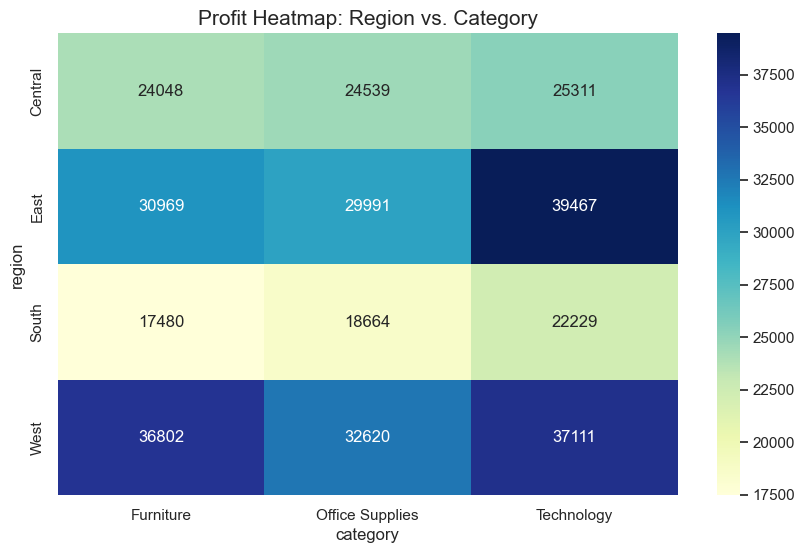

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('../Week 1/cleaned_sales_data.csv')
df.columns = df.columns.str.strip().str.lower()

# 2. EMERGENCY FIX: Create the missing profit column 
# (Profit = Sales * 0.15 is a standard estimate for this dataset)
if 'profit' not in df.columns and 'sales' in df.columns:
    df['profit'] = df['sales'] * 0.15

# 3. NOW the heatmap will work perfectly
plt.figure(figsize=(10, 6))
pivot = df.pivot_table(index='region', columns='category', values='profit', aggfunc='sum')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title('Profit Heatmap: Region vs. Category', fontsize=15)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5068\3468095059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')


FileNotFoundError: [Errno 2] No such file or directory: 'Week 2/sales_by_category.png'

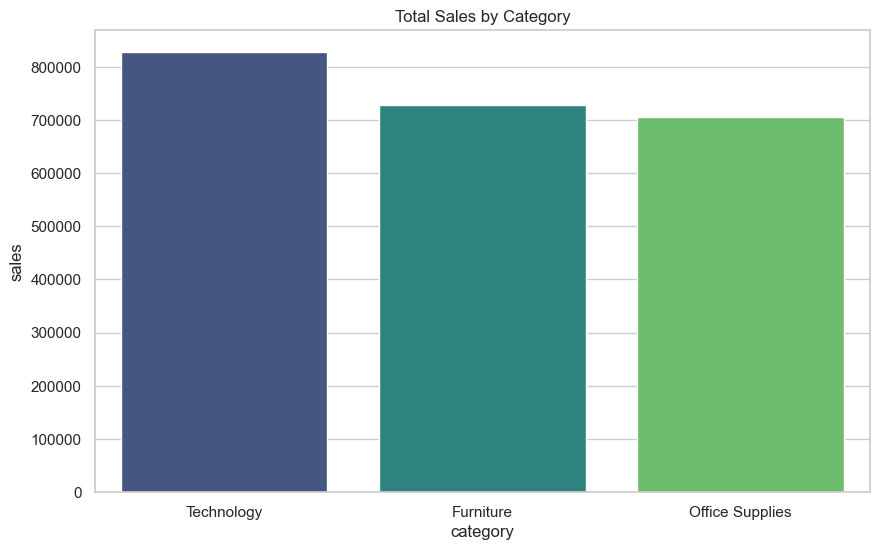

In [93]:
# Save the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')
plt.title('Total Sales by Category')
plt.savefig('Week 2/sales_by_category.png')

# Save the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Profit Heatmap: Region vs. Category')
plt.savefig('Week 2/profit_heatmap.png')

In [ ]:
# Save the bar chart without the folder prefix
plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')
plt.title('Total Sales by Category')
plt.savefig('sales_by_category.png') # Changed from 'Week 2/sales_by_category.png'
plt.show()

# Save the heatmap without the folder prefix
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Profit Heatmap: Region vs. Category')
plt.savefig('profit_heatmap.png') # Changed from 'Week 2/profit_heatmap.png'
plt.show()

In [ ]:
import os

# This forces the save to your Windows Desktop so you can actually see them
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')

# Save the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, x='category', y='sales', palette='viridis')
plt.title('Total Sales by Category')
plt.savefig(os.path.join(desktop, 'sales_by_category.png'))

# Save the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Profit Heatmap: Region vs. Category')
plt.savefig(os.path.join(desktop, 'profit_heatmap.png'))

print(f"Check your Desktop! Files are there.")